In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# ============= ЭТАП 1: ЗАГРУЗКА ДАННЫХ =============

print("="*50)
print("ЭТАП 1: ЗАГРУЗКА ДАННЫХ")
print("="*50)

# Загрузка справочников
print("\n1. Загрузка справочников...")
subjects = pd.read_csv('Идентификаторы Субъектов 10.04.2025.csv', sep=';')
mo = pd.read_csv('Идентификаторы МО 15.04.2025.csv')

# Загрузка связок
print("2. Загрузка связок пациент-программа...")
patient_program = pd.read_csv('МО и Пациенты 10.04.2025.csv', sep=';')
# Очищаем id пациента от всех видов пробелов
patient_program['id пациента'] = (patient_program['id пациента']
                                  .astype(str)
                                  .str.replace(r'\s+', '', regex=True)  # все пробельные символы
                                  .str.replace('\xa0', '', regex=False)  # неразрывный пробел
                                  .astype(int))
# Загрузка основных данных (с чанками для больших файлов)
print("3. Загрузка первичных данных (может занять время)...")
primary_chunks = []
chunk_size = 500000
for chunk in pd.read_csv('Первичные данные от 10.04.2025.csv', chunksize=chunk_size, sep=','):
    primary_chunks.append(chunk)
primary = pd.concat(primary_chunks, ignore_index=True)

print("4. Загрузка терапии...")
therapy = pd.read_csv('Медикаментозная терапия от 10.04.2025.csv')

print("5. Загрузка КЗС...")
kzs = pd.read_csv('Клинически значимые события от 15.04.2025.csv')

print(f"\nЗагружено:")
print(f"  Субъекты: {len(subjects)} строк")
print(f"  МО: {len(mo)} строк")
print(f"  Пациент-программа: {len(patient_program)} строк")
print(f"  Первичные данные: {len(primary):,} строк")
print(f"  Терапия: {len(therapy):,} строк")
print(f"  КЗС: {len(kzs):,} строк")

ЭТАП 1: ЗАГРУЗКА ДАННЫХ

1. Загрузка справочников...
2. Загрузка связок пациент-программа...
3. Загрузка первичных данных (может занять время)...
4. Загрузка терапии...
5. Загрузка КЗС...

Загружено:
  Субъекты: 19 строк
  МО: 119 строк
  Пациент-программа: 13943 строк
  Первичные данные: 4,888,853 строк
  Терапия: 23,798 строк
  КЗС: 1,243,036 строк


In [3]:
# ============= ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ =============

print("\n" + "="*50)
print("ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ")
print("="*50)

# Проверка наличия всех ID в справочниках
print("\n1. Проверка целостности связей:")
# Сначала добавляем id субъекта в patient_program по названию
print("Реальные колонки в subjects:", subjects.columns.tolist())
print("Реальные колонки в patient_program:", patient_program.columns.tolist())
patient_program['id пациента'] = patient_program['id пациента'].astype(str).str.replace(' ', '').astype(int)

# Теперь делаем merge с subjects
patient_program = patient_program.merge(
    subjects[['id субъекта', 'название субъекта']],
    on='название субъекта',
    how='left'
)

# Теперь проверяем
mo_in_patient = patient_program['id МО'].isin(mo['id МО']).mean()
print(f"  % id МО из patient_program, присутствующих в справочнике МО: {mo_in_patient*100:.1f}%")

subj_in_patient = patient_program['id субъекта'].notna().mean()
print(f"  % записей с найденным id субъекта: {subj_in_patient*100:.1f}%")

# Дубликаты в ключевых таблицах
print("\n2. Проверка дубликатов:")
print(f"  Дубликаты в subjects: {subjects.duplicated().sum()}")
print(f"  Дубликаты в mo: {mo.duplicated().sum()}")
print(f"  Дубликаты в patient_program: {patient_program.duplicated().sum()}")
print(f"  Дубликаты в primary (id пациента + время измерения): {primary.duplicated(['id пациента', 'время измерения']).sum():,}")

# ============= ЭТАП 3: ОЧИСТКА ДАННЫХ =============

print("\n" + "="*50)
print("ЭТАП 3: ОЧИСТКА ДАННЫХ")
print("="*50)

# 3.1 Работа с пропусками
print("\n1. Пропуски в первичных данных:")
primary_null = primary.isnull().sum()
primary_null_pct = (primary_null / len(primary)) * 100
null_df = pd.DataFrame({'Пропусков': primary_null, '%': primary_null_pct})
print(null_df[null_df['Пропусков'] > 0])

# 3.2 Форматы данных
print("\n2. Конвертация форматов...")
# Дата/время
primary['время измерения'] = pd.to_datetime(primary['время измерения'], errors='coerce')
primary['время сохранения на сервере'] = pd.to_datetime(primary['время сохранения на сервере'], errors='coerce')
primary['дата рождения пациента'] = pd.to_datetime(primary['дата рождения пациента'], errors='coerce')

therapy['дата начала программы'] = pd.to_datetime(therapy['дата начала программы'], errors='coerce')
therapy['дата назначения'] = pd.to_datetime(therapy['дата назначения'], errors='coerce')
therapy['дата начала приема'] = pd.to_datetime(therapy['дата начала приема'], errors='coerce')
therapy['дата окончания приема'] = pd.to_datetime(therapy['дата окончания приема'], errors='coerce')

kzs['дата, время формирования КЗС'] = pd.to_datetime(kzs['дата, время формирования КЗС'], errors='coerce')

# Числовые поля
primary['САД'] = pd.to_numeric(primary['САД'], errors='coerce')
primary['ДАД'] = pd.to_numeric(primary['ДАД'], errors='coerce')
primary['ЧП'] = pd.to_numeric(primary['ЧП'], errors='coerce')
primary['рост'] = pd.to_numeric(primary['рост'], errors='coerce')
primary['масса'] = pd.to_numeric(primary['масса'], errors='coerce')

# Расчет возраста на момент измерения
primary['возраст'] = (primary['время измерения'] - primary['дата рождения пациента']).dt.days / 365.25

print("  Конвертация завершена")

# ============= ЭТАП 4: OUTLIER ANALYSIS =============

print("\n" + "="*50)
print("ЭТАП 4: АНАЛИЗ ВЫБРОСОВ")
print("="*50)

# 4.1 Физиологические границы
print("\n1. Проверка физиологических границ:")

# САД
invalid_sbp = (primary['САД'] < 40) | (primary['САД'] > 250)
print(f"  САД вне нормы (40-250): {invalid_sbp.sum():,} ({invalid_sbp.mean()*100:.2f}%)")

# ДАД
invalid_dbp = (primary['ДАД'] < 30) | (primary['ДАД'] > 150) | (primary['ДАД'] > primary['САД'])
print(f"  ДАД вне нормы (30-150) или >САД: {(invalid_dbp).sum():,} ({invalid_dbp.mean()*100:.2f}%)")

# ЧП
invalid_hr = (primary['ЧП'] < 30) | (primary['ЧП'] > 220)
print(f"  ЧП вне нормы (30-220): {invalid_hr.sum():,} ({invalid_hr.mean()*100:.2f}%)")

# Возраст
invalid_age = (primary['возраст'] < 18) | (primary['возраст'] > 120)
print(f"  Возраст вне нормы (18-120): {invalid_age.sum():,} ({invalid_age.mean()*100:.2f}%)")

# 4.2 Аномалии по времени
print("\n2. Проверка временных аномалий:")

# Будущие измерения
future_meas = primary['время измерения'] > datetime.now()
print(f"  Измерения в будущем: {future_meas.sum():,} ({future_meas.mean()*100:.2f}%)")

# Слишком частые измерения (на одного пациента в день)
primary['date'] = primary['время измерения'].dt.date
patient_daily = primary.groupby(['id пациента', 'date']).size().reset_index(name='n_meas')
freq_meas = patient_daily[patient_daily['n_meas'] > 20]
print(f"  Пациенто-дней с >20 измерений: {len(freq_meas)} ({len(freq_meas)/len(patient_daily)*100:.2f}%)")


ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ

1. Проверка целостности связей:
Реальные колонки в subjects: ['id субъекта', 'название субъекта']
Реальные колонки в patient_program: ['название субъекта', 'id МО', 'id программы', 'группа наблюдения', 'id пациента']
  % id МО из patient_program, присутствующих в справочнике МО: 100.0%
  % записей с найденным id субъекта: 100.0%

2. Проверка дубликатов:
  Дубликаты в subjects: 0
  Дубликаты в mo: 0
  Дубликаты в patient_program: 0
  Дубликаты в primary (id пациента + время измерения): 78,817

ЭТАП 3: ОЧИСТКА ДАННЫХ

1. Пропуски в первичных данных:
                           Пропусков          %
код пациента                     461   0.009430
рост                         2202449  45.050424
масса                        2202449  45.050424
основное заболевание         2282276  46.683261
сопутствующие заболевание    2945472  60.248733

2. Конвертация форматов...
  Конвертация завершена

ЭТАП 4: АНАЛИЗ ВЫБРОСОВ

1. Проверка физиологических границ:
  САД вне нор


ЭТАП 5: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ

1. Распределение групп:
группа наблюдения
undefined     3788494
experience     878754
control_1      221605
Name: count, dtype: int64

Всего пациентов в группах: 4,888,853

2. Статистика измерений по группам:
                  id пациента    САД                  ДАД          ЧП      
                      nunique   mean   std    count  mean   std  mean   std
группа наблюдения                                                          
control_1                 369  128.7  17.1   221605  81.3  11.9  71.5  11.3
experience               1305  129.6  17.8   878754  81.3  11.6  71.3  11.5
undefined                9263  126.9  18.2  3788494  79.5  11.8  71.1  11.9

ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ

  Базовые графики сохранены в 'eda_basic_plots.png'

ЭТАП 7: АНАЛИЗ КЛИНИЧЕСКИ ЗНАЧИМЫХ СОБЫТИЙ

1. Топ-10 КЗС:
код КЗС
33921    449841
33923    192832
33911    156247
33430    107624
33922     85990
33913     40120
33431     34872
33901     26824
33924     20063
7

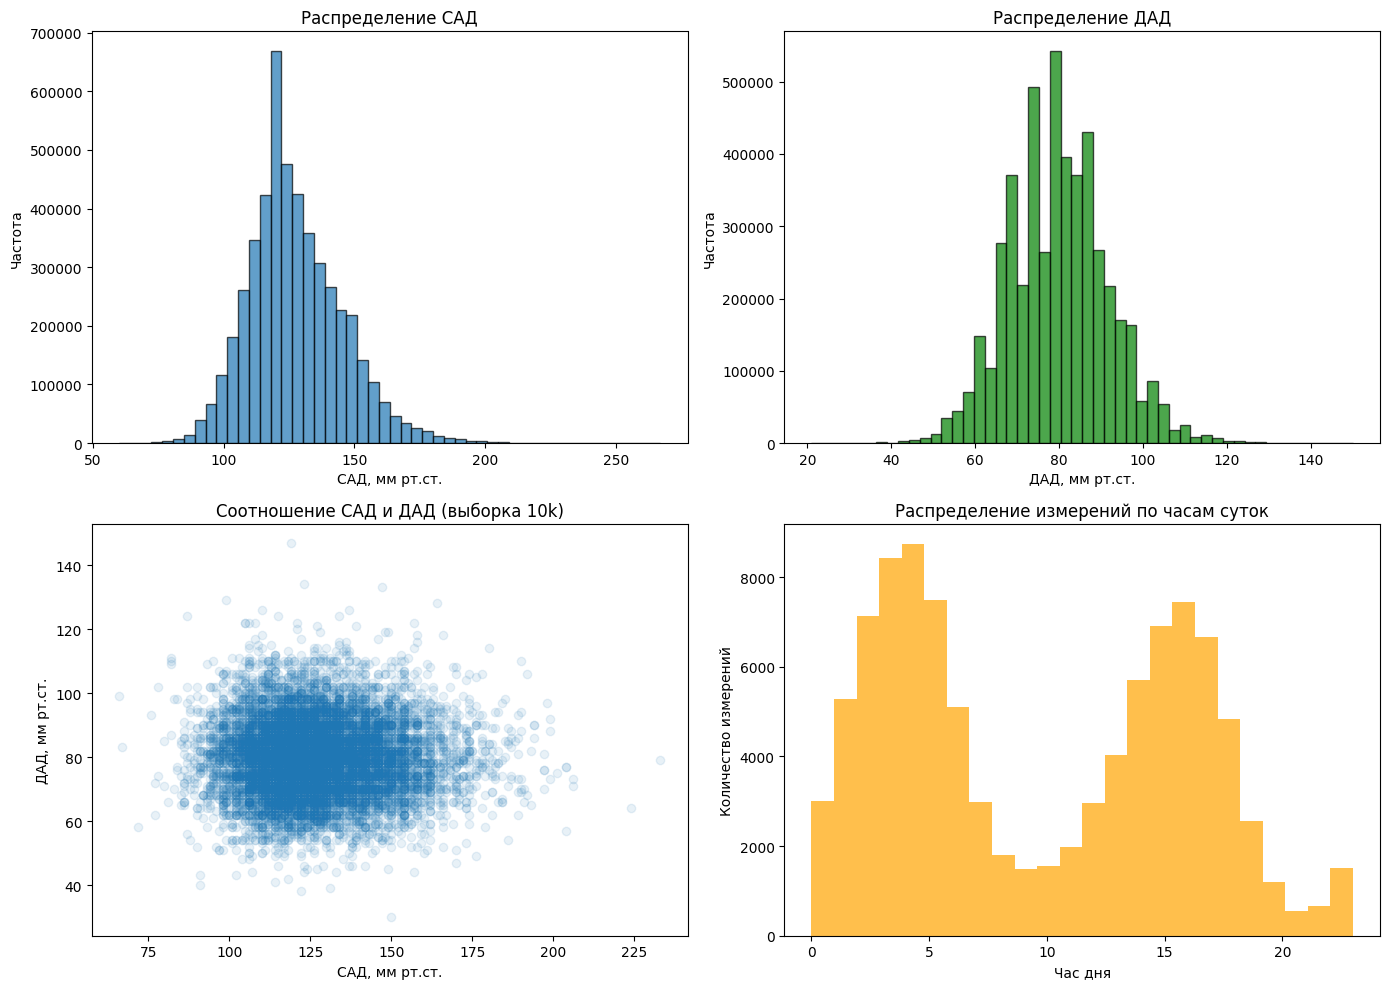

In [4]:
# ============= ЭТАП 5: АНАЛИЗ ПО ГРУППАМ =============

print("\n" + "="*50)
print("ЭТАП 5: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ")
print("="*50)

# Добавляем информацию о группе к первичным данным
primary = primary.merge(
    patient_program[['id пациента', 'группа наблюдения']].drop_duplicates('id пациента'),
    on='id пациента',
    how='left'
)

print("\n1. Распределение групп:")
group_dist = primary['группа наблюдения'].value_counts(dropna=False)
print(group_dist)
print(f"\nВсего пациентов в группах: {group_dist.sum():,}")

print("\n2. Статистика измерений по группам:")
group_stats = primary.groupby('группа наблюдения').agg({
    'id пациента': 'nunique',
    'САД': ['mean', 'std', 'count'],
    'ДАД': ['mean', 'std'],
    'ЧП': ['mean', 'std']
}).round(1)
print(group_stats)

# ============= ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ =============

print("\n" + "="*50)
print("ЭТАП 6: БАЗОВАЯ ВИЗУАЛИЗАЦИЯ")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Распределение САД
axes[0, 0].hist(primary['САД'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Распределение САД')
axes[0, 0].set_xlabel('САД, мм рт.ст.')
axes[0, 0].set_ylabel('Частота')

# 2. Распределение ДАД
axes[0, 1].hist(primary['ДАД'].dropna(), bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0, 1].set_title('Распределение ДАД')
axes[0, 1].set_xlabel('ДАД, мм рт.ст.')
axes[0, 1].set_ylabel('Частота')

# 3. Соотношение САД и ДАД
axes[1, 0].scatter(primary['САД'].sample(10000), primary['ДАД'].sample(10000), alpha=0.1)
axes[1, 0].set_title('Соотношение САД и ДАД (выборка 10k)')
axes[1, 0].set_xlabel('САД, мм рт.ст.')
axes[1, 0].set_ylabel('ДАД, мм рт.ст.')

# 4. Измерения по времени
primary_sample = primary.sample(min(100000, len(primary)))
axes[1, 1].hist(primary_sample['время измерения'].dt.hour.dropna(), bins=24, alpha=0.7, color='orange')
axes[1, 1].set_title('Распределение измерений по часам суток')
axes[1, 1].set_xlabel('Час дня')
axes[1, 1].set_ylabel('Количество измерений')

plt.tight_layout()
plt.savefig('eda_basic_plots.png', dpi=100)
print("\n  Базовые графики сохранены в 'eda_basic_plots.png'")

# ============= ЭТАП 7: КЗС АНАЛИЗ =============

print("\n" + "="*50)
print("ЭТАП 7: АНАЛИЗ КЛИНИЧЕСКИ ЗНАЧИМЫХ СОБЫТИЙ")
print("="*50)

# Топ событий
print("\n1. Топ-10 КЗС:")
top_kzs = kzs['код КЗС'].value_counts().head(10)
print(top_kzs)

# События на пациента
kzs_per_patient = kzs.groupby('id пациента').size()
print(f"\n2. Статистика КЗС на пациента:")
print(f"  Среднее: {kzs_per_patient.mean():.1f}")
print(f"  Медиана: {kzs_per_patient.median():.1f}")
print(f"  Макс: {kzs_per_patient.max():,}")
print(f"  % пациентов с КЗС: {(len(kzs_per_patient) / patient_program['id пациента'].nunique() * 100):.1f}%")

# ============= ЭТАП 8: ТЕРАПИЯ АНАЛИЗ =============

print("\n" + "="*50)
print("ЭТАП 8: АНАЛИЗ ТЕРАПИИ")
print("="*50)

print(f"\n1. Всего записей терапии: {len(therapy):,}")

if 'МНН' in therapy.columns:
    print("\n2. Топ-10 назначаемых МНН:")
    top_mnn = therapy['МНН'].value_counts().head(10)
    print(top_mnn)

print("\n3. Назначения по годам:")
therapy['год_назначения'] = therapy['дата назначения'].dt.year
print(therapy['год_назначения'].value_counts().sort_index())

# ============= ЭТАП 9: СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ =============

print("\n" + "="*50)
print("ЭТАП 9: СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ")
print("="*50)

# Удаляем явные выбросы для сохранения чистой версии
clean_primary = primary[
    ~invalid_sbp & 
    ~invalid_dbp & 
    ~invalid_hr & 
    ~invalid_age &
    ~future_meas
].copy()

print(f"\nИсходный размер primary: {len(primary):,}")
print(f"Размер после удаления выбросов: {len(clean_primary):,}")
print(f"Удалено: {len(primary) - len(clean_primary):,} записей ({(1 - len(clean_primary)/len(primary))*100:.1f}%)")
# Сохраняем для дальнейшего использования
clean_primary.to_csv('primary_clean.csv', index=False)
patient_program.to_csv('patient_program.csv', index=False)
kzs.to_csv('kzs.csv', index=False)
therapy.to_csv('therapy.csv', index=False)

print("\n  Очищенные данные сохранены в формате parquet:")
print("  - primary_clean.parquet")
print("  - patient_program.parquet")
print("  - kzs.parquet")
print("  - therapy.parquet")

# ============= ЭТАП 10: ИТОГОВАЯ ИНФОРМАЦИЯ =============

print("\n" + "="*50)
print("ИТОГОВАЯ ИНФОРМАЦИЯ")
print("="*50)

print(f"""
Статистика по очищенным данным:
- Пациентов всего: {patient_program['id пациента'].nunique():,}
- Медицинских организаций: {mo['id МО'].nunique():,}
- Субъектов РФ: {subjects['id субъекта'].nunique():,}
- Измерений (очищенных): {len(clean_primary):,}
- КЗС: {len(kzs):,}
- Записей терапии: {len(therapy):,}

Диапазон дат измерений:
  с {clean_primary['время измерения'].min()}
  по {clean_primary['время измерения'].max()}

Средние значения (по очищенным):
  САД: {clean_primary['САД'].mean():.1f} мм рт.ст.
  ДАД: {clean_primary['ДАД'].mean():.1f} мм рт.ст.
  ЧП: {clean_primary['ЧП'].mean():.1f} уд/мин
  Возраст: {clean_primary['возраст'].mean():.1f} лет
""")

print("\n✅ Подготовка данных завершена!")


ЭТАП 11: ВИЗУАЛИЗАЦИЯ И АНАЛИЗ
Тип данных 'время измерения': object
Первые 5 значений:
0    2024-09-27 00:25:32
1    2024-09-27 00:25:25
2    2024-09-27 00:24:57
3    2024-09-30 09:37:36
4    2024-09-30 09:37:50
Name: время измерения, dtype: object


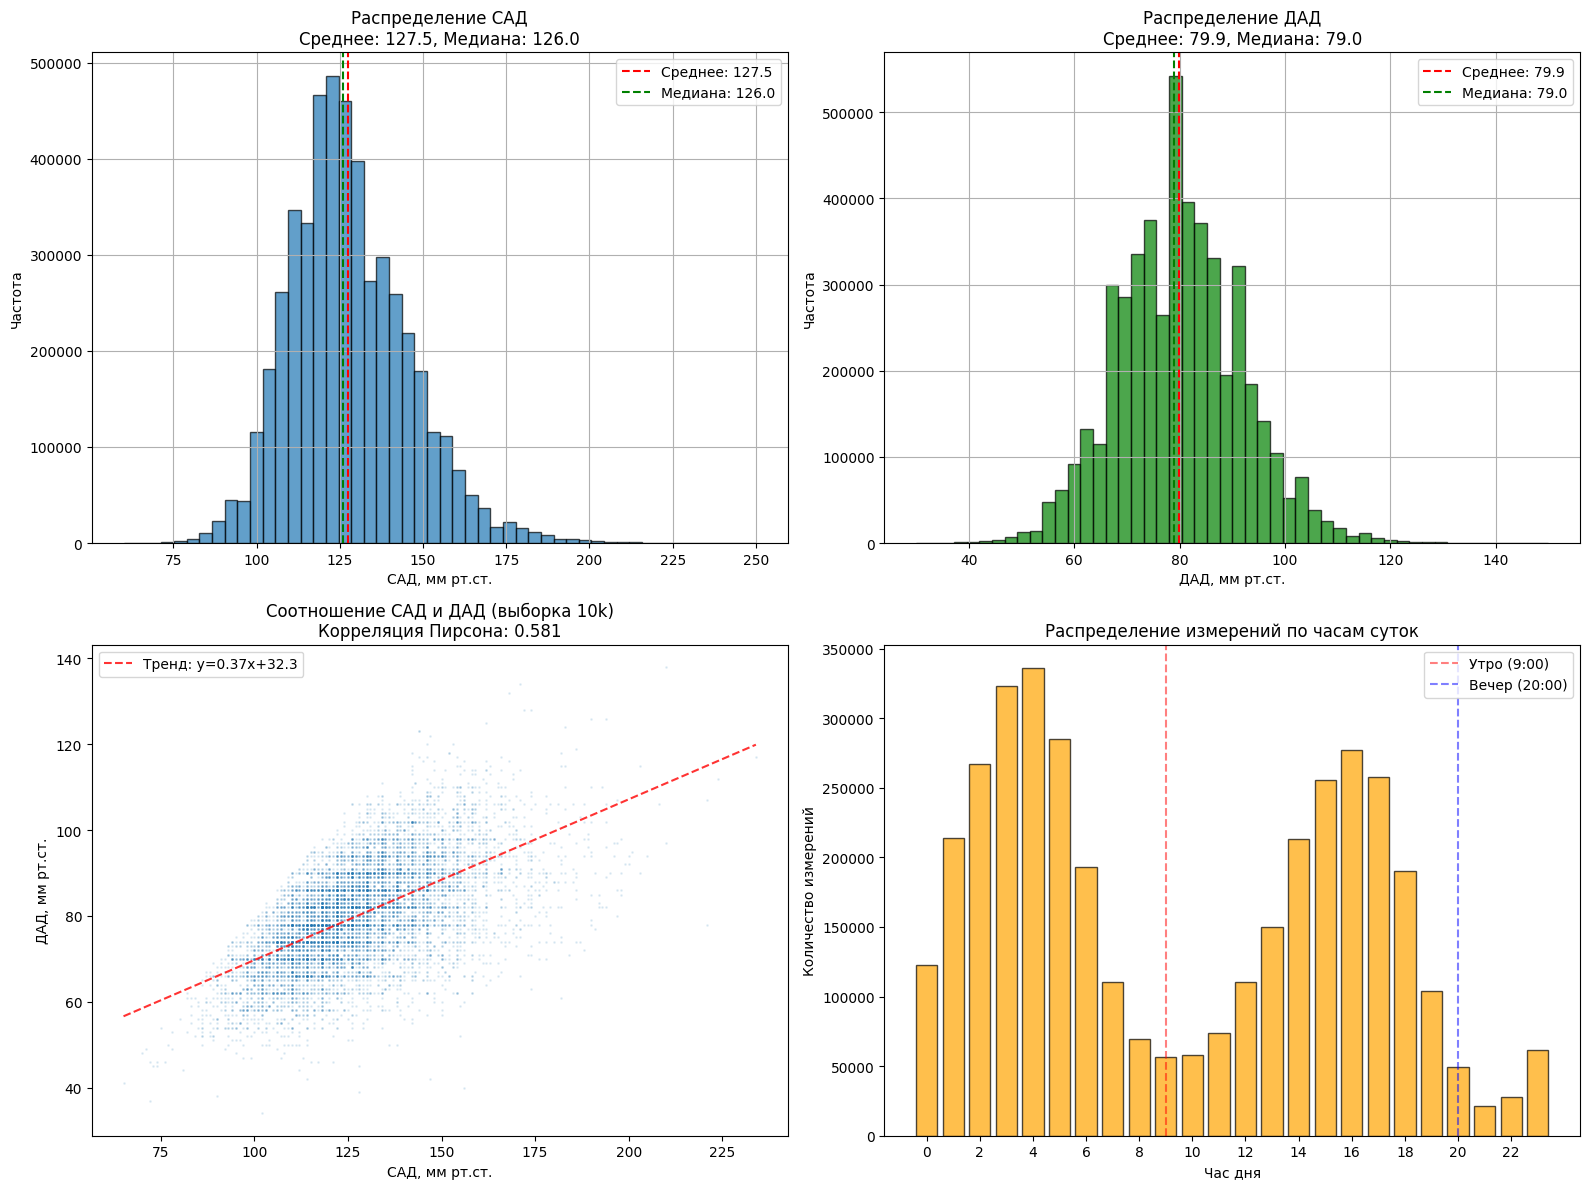


📊 Анализ графиков:

1. Распределение САД:
   - Среднее: 127.5 мм рт.ст.
   - Медиана: 126.0 мм рт.ст.
   - Стандартное отклонение: 18.1
   - 25-й перцентиль: 115.0
   - 75-й перцентиль: 138.0

2. Распределение ДАД:
   - Среднее: 79.9 мм рт.ст.
   - Медиана: 79.0 мм рт.ст.
   - Стандартное отклонение: 11.8
   - 25-й перцентиль: 72.0
   - 75-й перцентиль: 87.0

3. Корреляция САД и ДАД: 0.581
   - Умеренная положительная корреляция

4. Анализ времени измерений:
   - Утренние часы (6-10): 487,726 измерений (12.7%)
   - Вечерние часы (18-22): 393,172 измерений (10.3%)
   - Ночные часы (22-6): 1,637,362 измерений (42.8%)
   - Дневные часы (10-18): 1,310,158 измерений (34.2%)

ЭТАП 12: СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГРУПП

Статистика измерений по группам:
    Группа  Пациентов Ср. измерений Мед. измерений  Мин  Макс Сумма измерений
 control_1        369         600.5          467.0    1  4683         221,600
experience       1305         673.4          554.0    1  6204         878,726
 undefined      

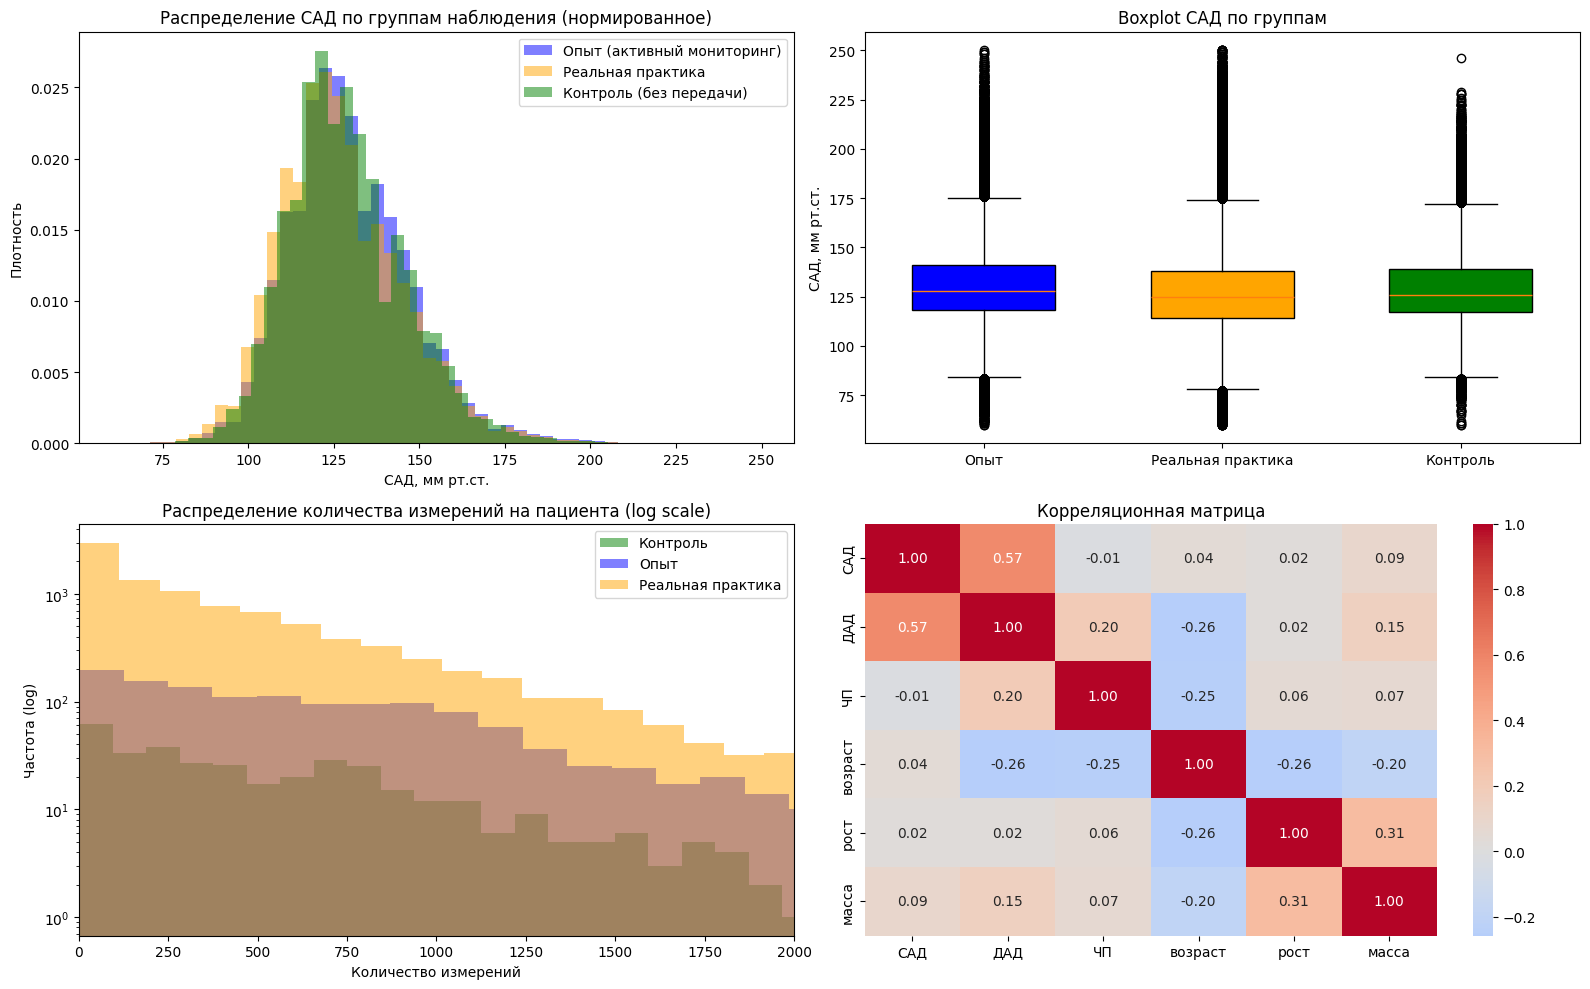


ЭТАП 13: АНАЛИЗ КАЧЕСТВА ДАННЫХ

1. Пропуски в критических полях по группам:
                   рост  масса  основное заболевание  \
группа наблюдения                                      
control_1          89.8   89.8                  96.9   
experience         88.1   88.1                  94.0   
undefined          32.4   32.4                  32.8   

                   сопутствующие заболевание  
группа наблюдения                             
control_1                               96.9  
experience                              94.1  
undefined                               50.3  

2. Регулярность измерений:
   - Пациенты с измерениями в 1 месяц: 869
   - Пациенты с измерениями в 2-6 месяцев: 5825
   - Пациенты с измерениями в 7+ месяцев: 3309

3. Задержка передачи данных (секунд):
   - Медиана: 3 сек
   - 90-й перцентиль: 5 сек
   - 95-й перцентиль: 22 сек
   - 99-й перцентиль: 48260 сек

   - Измерений с задержкой > 1 дня: 23542 (0.482%)

ЭТАП 14: СОХРАНЕНИЕ ОТЧЕТА

✅ Отчет сох

In [7]:
# ============= ЭТАП 11: ВИЗУАЛИЗАЦИЯ И АНАЛИЗ ГРАФИКОВ =============

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

print("\n" + "="*50)
print("ЭТАП 11: ВИЗУАЛИЗАЦИЯ И АНАЛИЗ")
print("="*50)

# Загружаем очищенные данные с явным указанием типов
clean_primary = pd.read_csv('primary_clean.csv', 
                           parse_dates=['время измерения', 'время сохранения на сервере', 'дата рождения пациента'])

# Проверяем тип данных
print(f"Тип данных 'время измерения': {clean_primary['время измерения'].dtype}")
print(f"Первые 5 значений:\n{clean_primary['время измерения'].head()}")

# Создаем улучшенные графики
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение САД с KDE
ax1 = axes[0, 0]
clean_primary['САД'].dropna().hist(bins=50, alpha=0.7, edgecolor='black', ax=ax1)
ax1.set_title('Распределение САД\nСреднее: {:.1f}, Медиана: {:.1f}'.format(
    clean_primary['САД'].mean(), clean_primary['САД'].median()))
ax1.set_xlabel('САД, мм рт.ст.')
ax1.set_ylabel('Частота')
ax1.axvline(clean_primary['САД'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {clean_primary["САД"].mean():.1f}')
ax1.axvline(clean_primary['САД'].median(), color='green', linestyle='--', 
            label=f'Медиана: {clean_primary["САД"].median():.1f}')
ax1.legend()

# 2. Распределение ДАД с KDE
ax2 = axes[0, 1]
clean_primary['ДАД'].dropna().hist(bins=50, alpha=0.7, edgecolor='black', color='green', ax=ax2)
ax2.set_title('Распределение ДАД\nСреднее: {:.1f}, Медиана: {:.1f}'.format(
    clean_primary['ДАД'].mean(), clean_primary['ДАД'].median()))
ax2.set_xlabel('ДАД, мм рт.ст.')
ax2.set_ylabel('Частота')
ax2.axvline(clean_primary['ДАД'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {clean_primary["ДАД"].mean():.1f}')
ax2.axvline(clean_primary['ДАД'].median(), color='green', linestyle='--', 
            label=f'Медиана: {clean_primary["ДАД"].median():.1f}')
ax2.legend()

# 3. Соотношение САД и ДАД с корреляцией
ax3 = axes[1, 0]
sample = clean_primary.sample(min(10000, len(clean_primary)))
ax3.scatter(sample['САД'], sample['ДАД'], alpha=0.1, s=1)
corr = sample['САД'].corr(sample['ДАД'])
ax3.set_title(f'Соотношение САД и ДАД (выборка 10k)\nКорреляция Пирсона: {corr:.3f}')
ax3.set_xlabel('САД, мм рт.ст.')
ax3.set_ylabel('ДАД, мм рт.ст.')

# Добавляем линию регрессии
z = np.polyfit(sample['САД'].dropna(), sample['ДАД'].dropna(), 1)
p = np.poly1d(z)
ax3.plot(sample['САД'].sort_values(), p(sample['САД'].sort_values()), 
         "r--", alpha=0.8, label=f'Тренд: y={z[0]:.2f}x+{z[1]:.1f}')
ax3.legend()

# 4. Распределение по часам (с проверкой типа данных)
ax4 = axes[1, 1]

# Явно преобразуем в datetime если ещё не
if not pd.api.types.is_datetime64_any_dtype(clean_primary['время измерения']):
    clean_primary['время измерения'] = pd.to_datetime(clean_primary['время измерения'], errors='coerce')

# Теперь извлекаем часы
hours = clean_primary['время измерения'].dt.hour.dropna()
hour_counts = hours.value_counts().sort_index()

ax4.bar(hour_counts.index, hour_counts.values, alpha=0.7, color='orange', edgecolor='black')
ax4.set_title('Распределение измерений по часам суток')
ax4.set_xlabel('Час дня')
ax4.set_ylabel('Количество измерений')
ax4.set_xticks(range(0, 24, 2))

# Добавляем вертикальные линии для утренних и вечерних пиков
ax4.axvline(x=9, color='red', linestyle='--', alpha=0.5, label='Утро (9:00)')
ax4.axvline(x=20, color='blue', linestyle='--', alpha=0.5, label='Вечер (20:00)')
ax4.legend()

plt.tight_layout()
plt.savefig('eda_detailed_plots.png', dpi=150)
plt.show()

print("\n📊 Анализ графиков:")
print("="*50)

print("\n1. Распределение САД:")
print(f"   - Среднее: {clean_primary['САД'].mean():.1f} мм рт.ст.")
print(f"   - Медиана: {clean_primary['САД'].median():.1f} мм рт.ст.")
print(f"   - Стандартное отклонение: {clean_primary['САД'].std():.1f}")
print(f"   - 25-й перцентиль: {clean_primary['САД'].quantile(0.25):.1f}")
print(f"   - 75-й перцентиль: {clean_primary['САД'].quantile(0.75):.1f}")

print("\n2. Распределение ДАД:")
print(f"   - Среднее: {clean_primary['ДАД'].mean():.1f} мм рт.ст.")
print(f"   - Медиана: {clean_primary['ДАД'].median():.1f} мм рт.ст.")
print(f"   - Стандартное отклонение: {clean_primary['ДАД'].std():.1f}")
print(f"   - 25-й перцентиль: {clean_primary['ДАД'].quantile(0.25):.1f}")
print(f"   - 75-й перцентиль: {clean_primary['ДАД'].quantile(0.75):.1f}")

print(f"\n3. Корреляция САД и ДАД: {corr:.3f}")
if corr > 0.7:
    print("   - Сильная положительная корреляция (ожидаемо для АД)")
elif corr > 0.5:
    print("   - Умеренная положительная корреляция")
else:
    print("   - Слабая корреляция (возможно, требует проверки)")

# Анализ времени измерений
peak_morning = hour_counts[6:10].sum() if 6 in hour_counts.index else 0
peak_evening = hour_counts[18:22].sum() if 18 in hour_counts.index else 0
night_meas = sum(hour_counts[h] for h in range(0, 6) if h in hour_counts.index) + \
            sum(hour_counts[h] for h in range(22, 24) if h in hour_counts.index)

total_meas = len(hours)
print("\n4. Анализ времени измерений:")
print(f"   - Утренние часы (6-10): {peak_morning:,} измерений ({peak_morning/total_meas*100:.1f}%)")
print(f"   - Вечерние часы (18-22): {peak_evening:,} измерений ({peak_evening/total_meas*100:.1f}%)")
print(f"   - Ночные часы (22-6): {night_meas:,} измерений ({night_meas/total_meas*100:.1f}%)")
print(f"   - Дневные часы (10-18): {total_meas - peak_morning - peak_evening - night_meas:,} измерений ({(total_meas - peak_morning - peak_evening - night_meas)/total_meas*100:.1f}%)")

# ============= ЭТАП 12: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ =============

print("\n" + "="*50)
print("ЭТАП 12: СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГРУПП")
print("="*50)

# Убедимся, что у нас есть группа наблюдения
if 'группа наблюдения' not in clean_primary.columns:
    # Загружаем patient_program для добавления группы
    patient_program = pd.read_csv('patient_program.csv')
    clean_primary = clean_primary.merge(
        patient_program[['id пациента', 'группа наблюдения']].drop_duplicates('id пациента'),
        on='id пациента',
        how='left'
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

groups = clean_primary['группа наблюдения'].dropna().unique()
colors = {'experience': 'blue', 'control_1': 'green', 'undefined': 'orange'}
color_map = {'experience': 'blue', 'control_1': 'green', 'undefined': 'orange'}

for i, group_name in enumerate(groups):
    group_data = clean_primary[clean_primary['группа наблюдения'] == group_name]
    
    if group_name == 'experience':
        label = 'Опыт (активный мониторинг)'
    elif group_name == 'control_1':
        label = 'Контроль (без передачи)'
    else:
        label = 'Реальная практика'
    
    # Распределение САД по группам
    axes[0, 0].hist(group_data['САД'].dropna(), bins=50, alpha=0.5, 
                    color=color_map.get(group_name, 'gray'), label=label, density=True)
    
    # Boxplot САД
    bp = axes[0, 1].boxplot(group_data['САД'].dropna(), positions=[i], widths=0.6,
                           patch_artist=True, 
                           boxprops=dict(facecolor=color_map.get(group_name, 'gray')))

axes[0, 0].set_title('Распределение САД по группам наблюдения (нормированное)')
axes[0, 0].set_xlabel('САД, мм рт.ст.')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].legend()

axes[0, 1].set_title('Boxplot САД по группам')
axes[0, 1].set_xticks(range(len(groups)))
axes[0, 1].set_xticklabels(['Опыт' if g=='experience' else 'Контроль' if g=='control_1' else 'Реальная практика' for g in groups])
axes[0, 1].set_ylabel('САД, мм рт.ст.')

# Количество измерений на пациента по группам
meas_per_patient = clean_primary.groupby(['группа наблюдения', 'id пациента']).size().reset_index(name='n_meas')
for group_name, group_data in meas_per_patient.groupby('группа наблюдения'):
    axes[1, 0].hist(group_data['n_meas'], bins=50, alpha=0.5, 
                    color=color_map.get(group_name, 'gray'), 
                    label=('Опыт' if group_name=='experience' else 'Контроль' if group_name=='control_1' else 'Реальная практика'), 
                    log=True)

axes[1, 0].set_title('Распределение количества измерений на пациента (log scale)')
axes[1, 0].set_xlabel('Количество измерений')
axes[1, 0].set_ylabel('Частота (log)')
axes[1, 0].legend()
axes[1, 0].set_xlim([0, 2000])

# Статистика по группам
group_stats = []
for group_name, group_data in meas_per_patient.groupby('группа наблюдения'):
    group_stats.append({
        'Группа': group_name,
        'Пациентов': len(group_data),
        'Ср. измерений': f"{group_data['n_meas'].mean():.1f}",
        'Мед. измерений': f"{group_data['n_meas'].median():.1f}",
        'Мин': group_data['n_meas'].min(),
        'Макс': group_data['n_meas'].max(),
        'Сумма измерений': f"{group_data['n_meas'].sum():,}"
    })

group_stats_df = pd.DataFrame(group_stats)
print("\nСтатистика измерений по группам:")
print(group_stats_df.to_string(index=False))

# Тепловая карта корреляций
numeric_cols = ['САД', 'ДАД', 'ЧП', 'возраст', 'рост', 'масса']
available_numeric = [col for col in numeric_cols if col in clean_primary.columns]
corr_matrix = clean_primary[available_numeric].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.savefig('eda_group_analysis.png', dpi=150)
plt.show()

# ============= ЭТАП 13: АНАЛИЗ КАЧЕСТВА ДАННЫХ =============

print("\n" + "="*50)
print("ЭТАП 13: АНАЛИЗ КАЧЕСТВА ДАННЫХ")
print("="*50)

# Пропуски по группам
print("\n1. Пропуски в критических полях по группам:")
missing_cols = ['рост', 'масса', 'основное заболевание', 'сопутствующие заболевание']
available_missing = [col for col in missing_cols if col in clean_primary.columns]

if available_missing:
    missing_by_group = clean_primary.groupby('группа наблюдения')[available_missing].agg(
        lambda x: x.isna().mean() * 100
    ).round(1)
    print(missing_by_group)
else:
    print("   Поля с пропусками не найдены в данных")

# Регулярность измерений
print("\n2. Регулярность измерений:")
clean_primary['год_месяц'] = clean_primary['время измерения'].dt.to_period('M')
meas_by_month = clean_primary.groupby(['id пациента', 'год_месяц']).size().reset_index(name='n_meas_month')
patients_with_regular_meas = meas_by_month.groupby('id пациента').size()

print(f"   - Пациенты с измерениями в 1 месяц: {(patients_with_regular_meas == 1).sum()}")
print(f"   - Пациенты с измерениями в 2-6 месяцев: {((patients_with_regular_meas >= 2) & (patients_with_regular_meas <= 6)).sum()}")
print(f"   - Пациенты с измерениями в 7+ месяцев: {(patients_with_regular_meas >= 7).sum()}")

# Временная задержка
if 'время сохранения на сервере' in clean_primary.columns:
    clean_primary['задержка_сек'] = (pd.to_datetime(clean_primary['время сохранения на сервере']) - 
                                     pd.to_datetime(clean_primary['время измерения'])).dt.total_seconds()
    delay_stats = clean_primary['задержка_сек'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    print(f"\n3. Задержка передачи данных (секунд):")
    print(f"   - Медиана: {delay_stats['50%']:.0f} сек")
    print(f"   - 90-й перцентиль: {delay_stats['90%']:.0f} сек")
    print(f"   - 95-й перцентиль: {delay_stats['95%']:.0f} сек")
    print(f"   - 99-й перцентиль: {delay_stats['99%']:.0f} сек")
    
    # Выявляем аномально большие задержки
    large_delay = clean_primary[clean_primary['задержка_сек'] > 86400]  # > 1 дня
    print(f"\n   - Измерений с задержкой > 1 дня: {len(large_delay)} ({len(large_delay)/len(clean_primary)*100:.3f}%)")
else:
    print("\n3. Информация о задержке передачи недоступна")

# ============= ЭТАП 14: СОХРАНЕНИЕ ОТЧЕТА =============

print("\n" + "="*50)
print("ЭТАП 14: СОХРАНЕНИЕ ОТЧЕТА")
print("="*50)

# Загружаем справочники для полного отчета
subjects = pd.read_csv('Идентификаторы Субъектов 10.04.2025.csv', sep=';')
mo = pd.read_csv('Идентификаторы МО 15.04.2025.csv')
patient_program = pd.read_csv('patient_program.csv')
kzs = pd.read_csv('kzs.csv')
therapy = pd.read_csv('therapy.csv')

with open('eda_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("ОТЧЕТ ПО РАЗВЕДОЧНОМУ АНАЛИЗУ ДАННЫХ (EDA)\n")
    f.write(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write("="*60 + "\n\n")
    
    f.write("1. ОБЩАЯ СТАТИСТИКА\n")
    f.write("-"*40 + "\n")
    f.write(f"Пациентов всего: {patient_program['id пациента'].nunique():,}\n")
    f.write(f"Пациентов с измерениями: {clean_primary['id пациента'].nunique():,}\n")
    f.write(f"Медицинских организаций: {mo['id МО'].nunique() if 'id МО' in mo.columns else len(mo):,}\n")
    f.write(f"Субъектов РФ: {subjects['id субъекта'].nunique() if 'id субъекта' in subjects.columns else len(subjects):,}\n")
    f.write(f"Измерений: {len(clean_primary):,}\n")
    f.write(f"КЗС: {len(kzs):,}\n")
    f.write(f"Записей терапии: {len(therapy):,}\n\n")
    
    f.write("2. КАЧЕСТВО ДАННЫХ\n")
    f.write("-"*40 + "\n")
    f.write(f"Дубликаты измерений: {primary.duplicated(['id пациента', 'время измерения']).sum():,}\n")
    f.write(f"Физиологические выбросы удалено: {len(primary) - len(clean_primary):,}\n")
    f.write(f"Пропуски в росте: {clean_primary['рост'].isna().mean()*100:.1f}%\n")
    f.write(f"Пропуски в весе: {clean_primary['масса'].isna().mean()*100:.1f}%\n\n")
    
    f.write("3. СТАТИСТИКА ИЗМЕРЕНИЙ\n")
    f.write("-"*40 + "\n")
    f.write(f"САД: среднее={clean_primary['САД'].mean():.1f}, мед={clean_primary['САД'].median():.1f}, std={clean_primary['САД'].std():.1f}\n")
    f.write(f"ДАД: среднее={clean_primary['ДАД'].mean():.1f}, мед={clean_primary['ДАД'].median():.1f}, std={clean_primary['ДАД'].std():.1f}\n")
    f.write(f"ЧП: среднее={clean_primary['ЧП'].mean():.1f}, мед={clean_primary['ЧП'].median():.1f}, std={clean_primary['ЧП'].std():.1f}\n")
    f.write(f"Возраст: среднее={clean_primary['возраст'].mean():.1f}, мед={clean_primary['возраст'].median():.1f}\n\n")
    
    f.write("4. ГРУППЫ НАБЛЮДЕНИЯ\n")
    f.write("-"*40 + "\n")
    f.write(group_stats_df.to_string(index=False))
    f.write("\n\n")
    
    f.write("5. ВРЕМЕННЫЕ ХАРАКТЕРИСТИКИ\n")
    f.write("-"*40 + "\n")
    f.write(f"Период данных: {clean_primary['время измерения'].min()} - {clean_primary['время измерения'].max()}\n")
    f.write(f"Утренние измерения (6-10): {peak_morning/total_meas*100:.1f}%\n")
    f.write(f"Вечерние измерения (18-22): {peak_evening/total_meas*100:.1f}%\n")
    if 'задержка_сек' in clean_primary.columns:
        f.write(f"Медиана задержки передачи: {delay_stats['50%']:.0f} сек\n")
        f.write(f"95% задержек: {delay_stats['95%']:.0f} сек\n")

print("\n✅ Отчет сохранен в 'eda_report.txt'")
print("📊 Графики сохранены:")
print("   - eda_detailed_plots.png")
print("   - eda_group_analysis.png")